# 1. Import Libraries

In [ ]:
# MODELING: supervised learning for mental-health text
# 1. Load train/test data
# 2. Data (text) cleaning (preserve ! ? and numbers)
# 3. Create linguistic features motivated by prior mental-health NLP research
# 4. Build multiple supervised models:
#    - Baseline: TF-IDF + Multinomial Logistic Regression
#    - Model Improvement: TF-IDF + Linear SVM
#    - Feature Improvement: Sentence Embeddings + Logistic Regression
#    - Combined: Sentence Embeddings + Linear SVM
#    - Advanced: Sentence Embeddings + Linguistic Features + Logistic Regression
#    - Optional: Random Forest / kNN on embeddings
#    - Optional: Fine-tuned transformer (DistilBERT)
# 5. Evaluate using:
#    - accuracy
#    - macro F1
#    - weighted F1
#    - per-class precision/recall/F1
#    - confusion matrix
#    - suicidal one-vs-rest PR-AUC
# so on...

In [1]:
# Imports needed for modeling
import os
import re
import math
import json
import random
import warnings
import numpy as np
import pandas as pd

from collections import Counter

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import contractions
import emoji

# Classical ML / evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    auc
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Sentence embeddings
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.style.use("default")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


C:\Users\Seyoung\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.pipeline import FeatureUnion

In [3]:
# Load labeled training data and unlabeled test data

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Basic cleanup
train_df["text"] = train_df["text"].fillna("").astype(str)
train_df["status"] = train_df["status"].astype(str)
test_df["text"] = test_df["text"].fillna("").astype(str)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain columns:", list(train_df.columns))
print("Test columns:", list(test_df.columns))

display(train_df.head())
display(test_df.head())

print("\nTraining class distribution:")
display(train_df["status"].value_counts())

Train shape: (41174, 3)
Test shape: (8436, 2)

Train columns: ['id', 'text', 'status']
Test columns: ['id', 'text']


,id,text,status
0,37183,i wish i wa in sydney,Normal
1,10228,being an adult is so fucking lonely. everyone ...,Suicidal
2,18073,"I would assume not, considering I could just f...",Suicidal
3,1576,I just realized that yesterday I haven't eaten...,Normal
4,12577,"Day #1Decided to not kill myself today, and I ...",Suicidal


,id,text
0,37716,be offline
1,17470,"I cannot fucking take this shit anymore, my fa..."
2,7630,I am in a really dark place right now and I ju...
3,9138,Its pointless. Fuck This world Yeah fuck it
4,11713,I have had a rough week or so. I have been thi...



Training class distribution:


status
Normal        16281
Depression    12397
Suicidal       9102
Anxiety        3394
Name: count, dtype: int64

# 2. Text Cleaning

In [4]:
# Text Cleaning
#
# Important fix:
# In the earlier notebook, punctuation like ! and ? was briefly preserved,
# but later a second regex removed it.
#
# This revised function keeps:
# - lowercase text
# - expanded contractions
# - no URLs / no @mentions
# - hashtag normalization (#sad -> sad)
# - repeated character normalization
# - digits
# - emotional punctuation ! and ?
#
# We keep ! and ? because they may signal emotional intensity in social media posts.

def clean_text_for_model(text):
    text = str(text)

    # Normalize curly apostrophes and similar variants
    text = text.replace("’", "'").replace("`", "'")

    # Lowercase for consistency
    text = text.lower()

    # Expand contractions: "can't" -> "cannot"
    text = contractions.fix(text)

    # Remove URLs.
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove HTML tags if any.
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove mentions like @username
    text = re.sub(r"@\w+", " ", text)

    # Normalize hashtags by removing # but keeping the word
    text = re.sub(r"#(\w+)", r"\1", text)

    # Convert emojis to text descriptions
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Normalize elongated words: "sooooo" -> "soo"
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Keep letters, digits, spaces, ! and ?
    text = re.sub(r"[^a-z0-9!? ]", " ", text)

    # Collapse repeated whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply corrected cleaning to both datasets.
train_df["clean_text_model"] = train_df["text"].apply(clean_text_for_model)
test_df["clean_text_model"] = test_df["text"].apply(clean_text_for_model)

display(train_df[["text", "clean_text_model"]].head(10))

,text,clean_text_model
0,i wish i wa in sydney,i wish i wa in sydney
1,being an adult is so fucking lonely. everyone ...,being an adult is so fucking lonely everyone i...
2,"I would assume not, considering I could just f...",i would assume not considering i could just fa...
3,I just realized that yesterday I haven't eaten...,i just realized that yesterday i have not eate...
4,"Day #1Decided to not kill myself today, and I ...",day 1decided to not kill myself today and i am...
5,yakedoshita,yakedoshita
6,17F. I’ve been fantasizing about this night si...,17f i have been fantasizing about this night s...
7,found 2 cockroaches on my bed and one in my cl...,found 2 cockroaches on my bed and one in my cl...
8,I had a moment earlier when I was setting up f...,i had a moment earlier when i was setting up f...
9,the one that stole a small plane?,the one that stole a small plane?


# 3. Linguistic Feature Engineering

In [5]:
# Linguistic feature engineering
#
# These features are motivated by psychological / mental-health language research.
# They are simple, interpretable, and can complement semantic embeddings.
#
# We include:
# - first-person pronoun frequency
# - negative emotion words
# - absolutist words
# - message length
# - punctuation features
# - question/exclamation ratio
# - uppercase ratio from original text
#
# These features are not meant to replace embeddings;
# they are designed to add interpretable signals.

FIRST_PERSON_PRONOUNS = {
    "i", "me", "my", "mine", "myself", "im", "i'm", "ive", "i've", "id", "i'd"
}

NEGATIVE_EMOTION_WORDS = {
    "sad", "hopeless", "worthless", "empty", "alone", "lonely", "tired",
    "cry", "crying", "hurt", "pain", "panic", "anxious", "anxiety",
    "depressed", "depression", "scared", "afraid", "miserable", "numb",
    "die", "dying", "death", "suicide", "kill", "killing", "harm", "selfharm",
    "stress", "stressed", "overwhelmed", "helpless", "burden", "burdensome"
}

ABSOLUTIST_WORDS = {
    "always", "nothing", "completely", "totally", "entirely", "absolutely",
    "every", "everyone", "everything", "never", "nobody", "noone", "all", "none"
}

def extract_linguistic_features(raw_text, clean_text):
    """
    Create interpretable numeric features from a post.

    Parameters
    - raw_text : str
        Original raw text, used for things like uppercase ratio.
    - clean_text : str
        Cleaned text, used for token-based counts.

    Returns
    - dict
        Dictionary of numeric features.
    """
    raw_text = str(raw_text)
    clean_text = str(clean_text)

    tokens = clean_text.split()
    n_tokens = max(len(tokens), 1)   # avoid division by zero
    n_chars = max(len(clean_text), 1)

    # Token-based lexical counts
    first_person_count = sum(token in FIRST_PERSON_PRONOUNS for token in tokens)
    negative_word_count = sum(token in NEGATIVE_EMOTION_WORDS for token in tokens)
    absolutist_count = sum(token in ABSOLUTIST_WORDS for token in tokens)

    # Character / punctuation signals
    exclamation_count = clean_text.count("!")
    question_count = clean_text.count("?")
    digit_count = sum(ch.isdigit() for ch in clean_text)

    # Raw text signal: uppercase proportion
    alpha_chars = [ch for ch in raw_text if ch.isalpha()]
    uppercase_ratio = (
        sum(ch.isupper() for ch in alpha_chars) / len(alpha_chars)
        if len(alpha_chars) > 0 else 0.0
    )

    # Length features
    avg_token_length = np.mean([len(t) for t in tokens]) if tokens else 0.0

    features = {
        "token_count": len(tokens),
        "char_count": len(clean_text),
        "avg_token_length": avg_token_length,
        "first_person_count": first_person_count,
        "first_person_ratio": first_person_count / n_tokens,
        "negative_word_count": negative_word_count,
        "negative_word_ratio": negative_word_count / n_tokens,
        "absolutist_count": absolutist_count,
        "absolutist_ratio": absolutist_count / n_tokens,
        "exclamation_count": exclamation_count,
        "question_count": question_count,
        "digit_count": digit_count,
        "uppercase_ratio": uppercase_ratio,
        "exclamation_ratio": exclamation_count / n_chars,
        "question_ratio": question_count / n_chars,
    }

    return features

# Build feature tables for train and test
train_ling = pd.DataFrame([
    extract_linguistic_features(raw, clean)
    for raw, clean in zip(train_df["text"], train_df["clean_text_model"])
])

test_ling = pd.DataFrame([
    extract_linguistic_features(raw, clean)
    for raw, clean in zip(test_df["text"], test_df["clean_text_model"])
])

print("Linguistic feature shape (train):", train_ling.shape)
display(train_ling.head())

Linguistic feature shape (train): (41174, 15)


,token_count,char_count,avg_token_length,first_person_count,first_person_ratio,negative_word_count,negative_word_ratio,absolutist_count,absolutist_ratio,exclamation_count,question_count,digit_count,uppercase_ratio,exclamation_ratio,question_ratio
0,6,21,2.666667,2,0.333333,0,0.000000,0,0.000000,0,0,0,0.000000,0.000000,0.000000
1,184,901,3.902174,23,0.125000,6,0.032609,4,0.021739,0,0,0,0.001393,0.000000,0.000000
2,25,119,3.800000,4,0.160000,1,0.040000,0,0.000000,0,2,0,0.043011,0.000000,0.016807
3,50,259,4.200000,5,0.100000,0,0.000000,3,0.060000,1,0,0,0.034483,0.003861,0.000000
4,87,415,3.781609,11,0.126437,2,0.022989,1,0.011494,0,0,13,0.050633,0.000000,0.000000


# 4. Validation Split

In [6]:
# Encode labels and create a validation split
#
# We do not use test.csv for evaluation because it is unlabeled.
# Instead:
# - split the labeled training set into train/validation
# - use cross-validation for more rigorous model comparison
# - later retrain the best model on the full training set

label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(train_df["status"])

print("Label mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{cls} -> {i}")

X_text_all = train_df["clean_text_model"].copy()

X_train_text, X_val_text, y_train, y_val, idx_train, idx_val = train_test_split(
    X_text_all,
    y_all,
    train_df.index,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_all
)

# Slice corresponding linguistic features
X_train_ling = train_ling.loc[idx_train].reset_index(drop=True)
X_val_ling = train_ling.loc[idx_val].reset_index(drop=True)

# Reset text indices for convenience
X_train_text = X_train_text.reset_index(drop=True)
X_val_text = X_val_text.reset_index(drop=True)

# Also keep raw labels for readable output
y_train_labels = label_encoder.inverse_transform(y_train)
y_val_labels = label_encoder.inverse_transform(y_val)

print("Training split size:", len(X_train_text))
print("Validation split size:", len(X_val_text))

print("\nValidation class distribution:")
print(pd.Series(y_val_labels).value_counts())

Label mapping:
Anxiety -> 0
Depression -> 1
Normal -> 2
Suicidal -> 3
Training split size: 32939
Validation split size: 8235

Validation class distribution:
Normal        3256
Depression    2480
Suicidal      1820
Anxiety        679
Name: count, dtype: int64


## Helper for Evaluation Metrics

In [7]:
# Helper functions for evaluation

def plot_confusion(y_true, y_pred, class_names, title):
    """
    Plot confusion matrix with readable class labels.
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()


def suicidal_pr_auc_from_probs(y_true, y_prob, class_names):
    """
    Compute one-vs-rest PR-AUC for the Suicidal class.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        Integer-encoded labels.
    y_prob : array-like of shape (n_samples, n_classes)
        Predicted probabilities for each class.
    class_names : list-like
        Names of classes in encoder order.

    Returns
    -------
    dict
        precision, recall, thresholds, average_precision, and area under PR curve.
    """
    suicidal_index = list(class_names).index("Suicidal")

    # Convert multiclass labels into binary:
    # 1 if suicidal, 0 otherwise
    y_true_binary = (np.array(y_true) == suicidal_index).astype(int)
    suicidal_probs = y_prob[:, suicidal_index]

    precision, recall, thresholds = precision_recall_curve(y_true_binary, suicidal_probs)
    pr_auc = auc(recall, precision)
    ap = average_precision_score(y_true_binary, suicidal_probs)

    return {
        "precision": precision,
        "recall": recall,
        "thresholds": thresholds,
        "pr_auc": pr_auc,
        "average_precision": ap
    }


def plot_pr_curve(pr_dict, title):
    """
    Plot precision-recall curve for suicidal detection.
    """
    plt.figure(figsize=(6, 5))
    plt.plot(pr_dict["recall"], pr_dict["precision"], linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title}\nPR-AUC = {pr_dict['pr_auc']:.4f}, AP = {pr_dict['average_precision']:.4f}")
    plt.tight_layout()
    plt.show()


def evaluate_classifier(model_name, model, X_train, y_train, X_val, y_val, class_names, has_predict_proba=True):
    """
    Fit a classifier, evaluate it on validation data, and return metrics.

    This function:
    - trains the model
    - computes predictions on validation data
    - prints overall metrics
    - prints per-class report
    - plots confusion matrix
    - if probabilities are available, computes suicidal PR-AUC
    """
    print("=" * 80)
    print(f"MODEL: {model_name}")
    print("=" * 80)

    # Fit the model on training data.
    model.fit(X_train, y_train)

    # Predict validation labels.
    y_pred = model.predict(X_val)

    # Overall metrics.
    acc = accuracy_score(y_val, y_pred)
    macro_f1 = f1_score(y_val, y_pred, average="macro")
    weighted_f1 = f1_score(y_val, y_pred, average="weighted")
    macro_precision = precision_score(y_val, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_val, y_pred, average="macro", zero_division=0)

    print(f"Accuracy:      {acc:.4f}")
    print(f"Macro F1:      {macro_f1:.4f}")
    print(f"Weighted F1:   {weighted_f1:.4f}")
    print(f"Macro Prec.:   {macro_precision:.4f}")
    print(f"Macro Recall:  {macro_recall:.4f}\n")

    print("Classification report:")
    print(classification_report(
        y_val,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    ))

    plot_confusion(
        y_true=y_val,
        y_pred=y_pred,
        class_names=class_names,
        title=f"Confusion Matrix: {model_name}"
    )

    results = {
        "model": model_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall
    }

    # Probability-based evaluation for suicidal detection
    if has_predict_proba:
        y_prob = model.predict_proba(X_val)
        pr_dict = suicidal_pr_auc_from_probs(y_val, y_prob, class_names)

        print(f"Suicidal one-vs-rest PR-AUC: {pr_dict['pr_auc']:.4f}")
        print(f"Suicidal Average Precision:  {pr_dict['average_precision']:.4f}")

        plot_pr_curve(pr_dict, title=f"Suicidal Detection PR Curve: {model_name}")

        results["suicidal_pr_auc"] = pr_dict["pr_auc"]
        results["suicidal_average_precision"] = pr_dict["average_precision"]

    return results

## Helper for CV (K-fold)

In [8]:
# Cross-validation helper
#
# This is important because one train/validation split can be lucky or unlucky.
# Stratified K-fold preserves class proportions in each fold.

def cross_validate_model(model_name, model, X, y):
    """
    Run 5-fold stratified cross-validation and return mean/std metrics.
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    scoring = {
        "accuracy": "accuracy",
        "macro_f1": "f1_macro",
        "weighted_f1": "f1_weighted"
    }

    cv_results = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=None,
        return_train_score=False
    )

    summary = {
        "model": model_name,
        "cv_accuracy_mean": np.mean(cv_results["test_accuracy"]),
        "cv_accuracy_std": np.std(cv_results["test_accuracy"]),
        "cv_macro_f1_mean": np.mean(cv_results["test_macro_f1"]),
        "cv_macro_f1_std": np.std(cv_results["test_macro_f1"]),
        "cv_weighted_f1_mean": np.mean(cv_results["test_weighted_f1"]),
        "cv_weighted_f1_std": np.std(cv_results["test_weighted_f1"]),
    }

    print(f"\nCross-validation summary for {model_name}")
    for k, v in summary.items():
        if k != "model":
            print(f"{k}: {v:.4f}")

    return summary

# 5-1. Models (with TF-IDF)

## 1. Word TF-IDF + LR

MODEL: TF-IDF + Multinomial Logistic Regression
Accuracy:      0.7864
Macro F1:      0.7632
Weighted F1:   0.7852
Macro Prec.:   0.7553
Macro Recall:  0.7739

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.7071    0.8071    0.7538       679
  Depression     0.7418    0.6685    0.7033      2480
      Normal     0.8989    0.9205    0.9096      3256
    Suicidal     0.6732    0.6995    0.6861      1820

    accuracy                         0.7864      8235
   macro avg     0.7553    0.7739    0.7632      8235
weighted avg     0.7859    0.7864    0.7852      8235



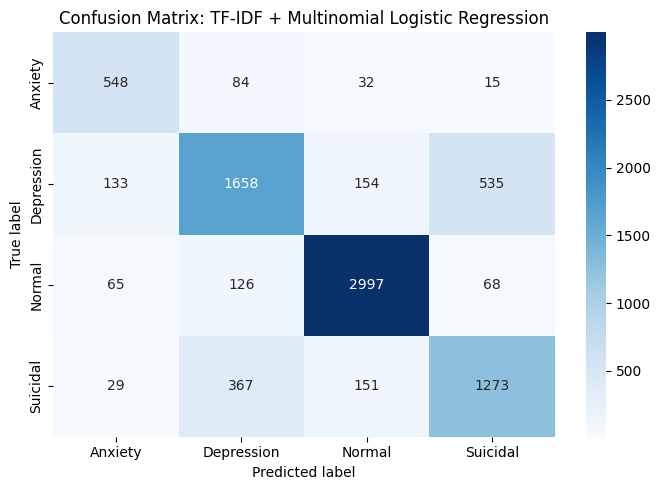

Suicidal one-vs-rest PR-AUC: 0.7166
Suicidal Average Precision:  0.7168


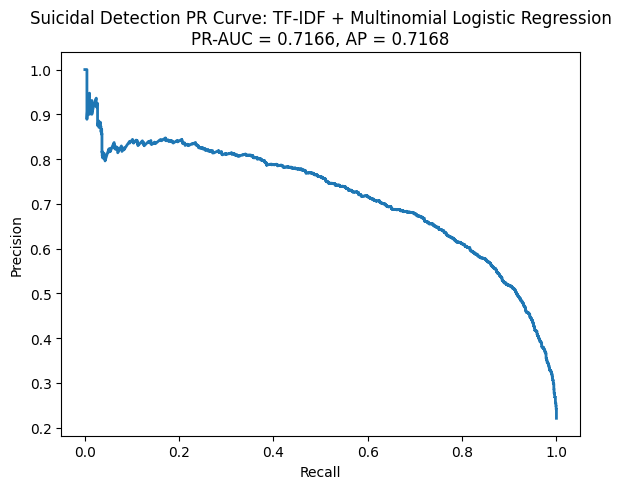


Cross-validation summary for TF-IDF + Multinomial Logistic Regression
cv_accuracy_mean: 0.7879
cv_accuracy_std: 0.0051
cv_macro_f1_mean: 0.7639
cv_macro_f1_std: 0.0053
cv_weighted_f1_mean: 0.7867
cv_weighted_f1_std: 0.0051


In [9]:
# Model 1 (Baseline): TF-IDF + Multinomial Logistic Regression
#
# Why this model?
# - Very strong classical baseline for text classification
# - Interpretable and fast
# - Often surprisingly competitive
#
# Why class_weight="balanced"?
# - The suicidal class is smaller than Normal / Depression
# - Balanced weights reduce bias toward the majority classes

tfidf_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),      # unigrams + bigrams
        min_df=3,                # ignore extremely rare terms
        max_df=0.95,             # ignore very common near-stopword terms
        sublinear_tf=True,       # log-scale term frequency
        strip_accents="unicode"
    )),

    # multi_class is just telling logistic regression how to handle more than 2 classes. 
    # but, scikit-learn is already choosing the multiclass behavior automatically,
    # so multiclass argument is unnecessary.
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

res_tfidf_logreg = evaluate_classifier(
    model_name="TF-IDF + Multinomial Logistic Regression",
    model=tfidf_logreg,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_tfidf_logreg = cross_validate_model(
    model_name="TF-IDF + Multinomial Logistic Regression",
    model=tfidf_logreg,
    X=X_text_all,
    y=y_all
)

## 2. Word TF-IDF + SVM

MODEL: TF-IDF + Calibrated Linear SVM
Accuracy:      0.7925
Macro F1:      0.7674
Weighted F1:   0.7894
Macro Prec.:   0.7859
Macro Recall:  0.7535

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.8437    0.6996    0.7649       679
  Depression     0.7187    0.7242    0.7214      2480
      Normal     0.8807    0.9478    0.9130      3256
    Suicidal     0.7004    0.6423    0.6701      1820

    accuracy                         0.7925      8235
   macro avg     0.7859    0.7535    0.7674      8235
weighted avg     0.7890    0.7925    0.7894      8235



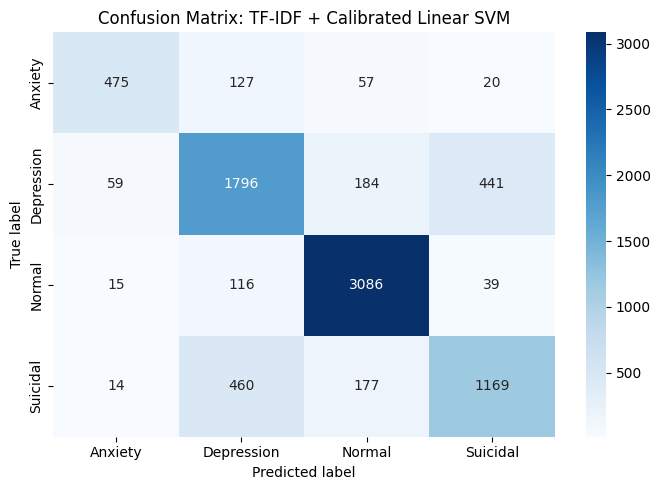

Suicidal one-vs-rest PR-AUC: 0.7232
Suicidal Average Precision:  0.7234


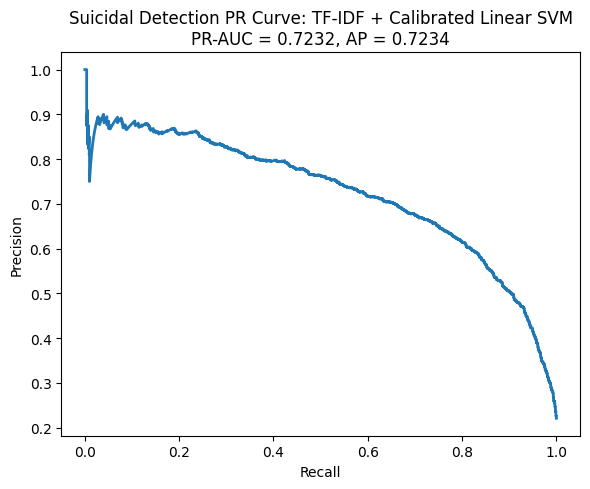


Cross-validation summary for TF-IDF + Calibrated Linear SVM
cv_accuracy_mean: 0.7931
cv_accuracy_std: 0.0031
cv_macro_f1_mean: 0.7672
cv_macro_f1_std: 0.0040
cv_weighted_f1_mean: 0.7900
cv_weighted_f1_std: 0.0031


In [10]:
# Model 2 (Model Improvement): TF-IDF + Linear SVM
#
# Why Linear SVM here?
# - SVM often works better than logistic regression in high-dimensional spaces
# - it is strong for text classification
# - we already saw SVM outperform logistic regression in TF-IDF models
#
# Why calibrated SVM?
# - LinearSVC does not output probabilities by default
# - calibration lets us estimate probabilities
# - that allows us to compute PR-AUC for the Suicidal class

base_linear_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True,
        strip_accents="unicode"
    )),
    ("svm", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Calibrate margins into probabilities using cross-validated calibration.
tfidf_svm = CalibratedClassifierCV(
    estimator=base_linear_svm,
    method="sigmoid",
    cv=3
)

res_tfidf_svm = evaluate_classifier(
    model_name="TF-IDF + Calibrated Linear SVM",
    model=tfidf_svm,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_tfidf_svm = cross_validate_model(
    model_name="TF-IDF + Calibrated Linear SVM",
    model=tfidf_svm,
    X=X_text_all,
    y=y_all
)

### Why PR-AUC for Suicidal Class

We used PR-AUC for the suicidal class because overall accuracy alone is not sufficient for evaluating high-risk detection. We have noticed the presence of clear class imbalance where suicidal posts are less common than normal posts. Then a model can get decent accuracy just by predicting the larger classes well, even if it misses many suicidal posts.So accuracy can hide poor high-risk detection.

PR-AUC focuses on:
- Precision: when the model flags a post as suicidal, how often is it correct?
- Recall: how many truly suicidal posts did the model successfully find?

In a mental-health screening setting, the most important question is whether the model can reliably identify suicidal posts while balancing false alarms and missed cases. PR-AUC is useful because for early intervention which aligns with our research question of achieving detecting high-risk posts, we want a model that can identify suicidal posts well, not just do well overall.

### SVM outperforms LR
The TF-IDF + Linear SVM model performed slightly better than TF-IDF + Logistic Regression on all major metrics. Logistic Regression achieved an accuracy of 0.7864, macro-F1 of 0.7632, and suicidal PR-AUC of 0.7166, while the SVM achieved an accuracy of 0.7925, macro-F1 of 0.7674, and suicidal PR-AUC of 0.7232. Although the improvement was modest, it was consistent across all metrics, so the SVM was preferred. 

### Word TF-IDF to Word + Character TF-IDF
Our initial baseline model used TF-IDF with word n-grams, which represents each post based on the frequency and importance of words in the dataset. This approach is widely used in classical text classification and performed well in our early experiments.

Word n-gram analyzes normal words such as:

- depressed
- want to die

In the cases where we have spelling mistake or informal text, a standard word-based TF-IDF model may fail to recognize the words because they are misspelled or written informally. To address this limitation, we extended the feature representation to a hybrid TF-IDF model that combines word n-grams and character n-grams.

Character n-grams help the model recognize misspelled or informal text, which is common in social media posts. For example:

- “I want to kill myself”

- “I wanna kil mes”

- “im depresed and tired”

These subword patterns remain similar even when words are misspelled or abbreviated. As a result, the hybrid representation allows the model to detect linguistic patterns that would otherwise be missed by word-only TF-IDF features. This improvement is particularly important for social media and mental health text analysis, where language is often informal and inconsistent.

## 3. Hybrid TF-IDF + SVM

MODEL: Hybrid TF-IDF (word+char) + Linear SVM
Accuracy:      0.7971
Macro F1:      0.7731
Weighted F1:   0.7943
Macro Prec.:   0.7889
Macro Recall:  0.7608

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.8458    0.7187    0.7771       679
  Depression     0.7262    0.7262    0.7262      2480
      Normal     0.8900    0.9515    0.9197      3256
    Suicidal     0.6936    0.6467    0.6693      1820

    accuracy                         0.7971      8235
   macro avg     0.7889    0.7608    0.7731      8235
weighted avg     0.7936    0.7971    0.7943      8235



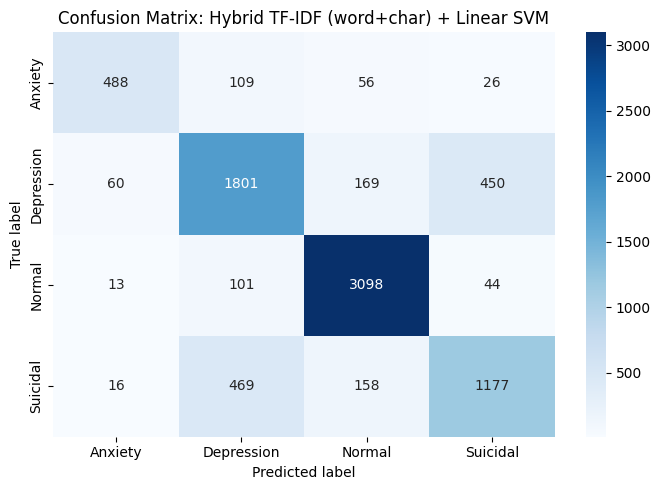

Suicidal one-vs-rest PR-AUC: 0.7225
Suicidal Average Precision:  0.7227


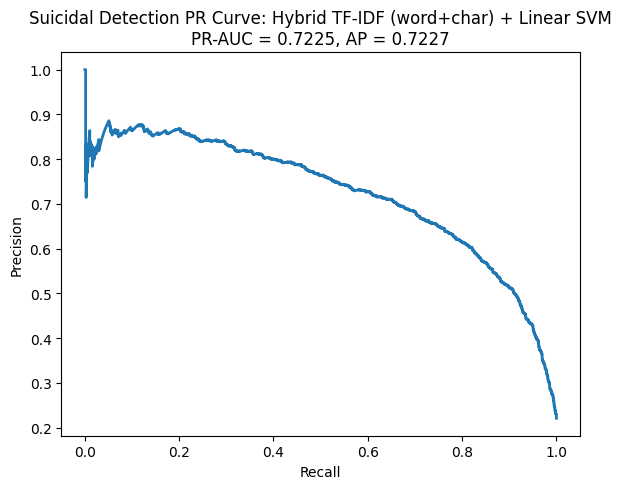


Cross-validation summary for Hybrid TF-IDF (word+char) + Linear SVM
cv_accuracy_mean: 0.7972
cv_accuracy_std: 0.0035
cv_macro_f1_mean: 0.7721
cv_macro_f1_std: 0.0036
cv_weighted_f1_mean: 0.7945
cv_weighted_f1_std: 0.0034


In [ ]:
# Improved Model: Hybrid TF-IDF (word + character) + Linear SVM

word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1,2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",  # character n-grams within word boundaries
    ngram_range=(3,5),
    min_df=3,
    sublinear_tf=True
)

hybrid_tfidf = FeatureUnion([
    ("word", word_tfidf),
    ("char", char_tfidf)
])

base_hybrid_svm = Pipeline([
    ("features", hybrid_tfidf),
    ("svm", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

hybrid_svm = CalibratedClassifierCV(
    estimator=base_hybrid_svm,
    method="sigmoid",
    cv=3
)

res_hybrid_svm = evaluate_classifier(
    model_name="Hybrid TF-IDF (word+char) + Linear SVM",
    model=hybrid_svm,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_hybrid_svm = cross_validate_model(
    model_name="Hybrid TF-IDF (word+char) + Linear SVM",
    model=hybrid_svm,
    X=X_text_all,
    y=y_all
)

### Parameter Tuning (Grid Search)

Grid search was used to tune the SVM regularization parameter C, which controls the trade-off between fitting the training data and generalizing to unseen data.
- If C is too large, the model may overfit the training data.
- If C is too small, the model may underfit and fail to capture important patterns.

Grid search systematically evaluates multiple candidate values of C. In our experiment, we tested: C∈{0.1,  0.5,  1,  2,  5}. Testing a limited number of values keeps the tuning process computationally efficient, while still exploring a meaningful range of model behaviors.

We evaluated several candidate values using 3-fold cross-validation and selected the parameter that maximized macro-F1 score. The best value C=0.1 produced a cross-validated macro-F1 of 0.769 and slightly improved overall model performance.

We used macro-F1 score as the tuning metric because:
- target is multi-class
- dataset contains class imbalance
- macro-F1 evaluates performance equally across all classes

In [12]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for Hybrid TF-IDF + Linear SVM
#
# We tune the SVM regularization parameter C.
# This helps us find the best balance between:
# - fitting the training data
# - generalizing well to new data
#
# We use macro F1 as the tuning metric because:
# - this is a multiclass problem
# - classes are imbalanced
# - we want balanced performance across all classes

param_grid = {
    "estimator__svm__C": [0.1, 0.5, 1, 2, 5]
}

grid_hybrid_svm = GridSearchCV(
    estimator=hybrid_svm,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_hybrid_svm.fit(X_train_text, y_train)

print("Best parameters found:")
print(grid_hybrid_svm.best_params_)

print("\nBest cross-validated macro F1:")
print(grid_hybrid_svm.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters found:
{'estimator__svm__C': 0.1}

Best cross-validated macro F1:
0.769229265546072


## 4. Tuned hybrid TF-IDF + SVM

MODEL: Tuned Hybrid TF-IDF (word+char) + Linear SVM
Accuracy:      0.7948
Macro F1:      0.7709
Weighted F1:   0.7916
Macro Prec.:   0.7828
Macro Recall:  0.7614

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.8209    0.7290    0.7722       679
  Depression     0.7317    0.7093    0.7203      2480
      Normal     0.8801    0.9512    0.9142      3256
    Suicidal     0.6987    0.6560    0.6767      1820

    accuracy                         0.7948      8235
   macro avg     0.7828    0.7614    0.7709      8235
weighted avg     0.7904    0.7948    0.7916      8235



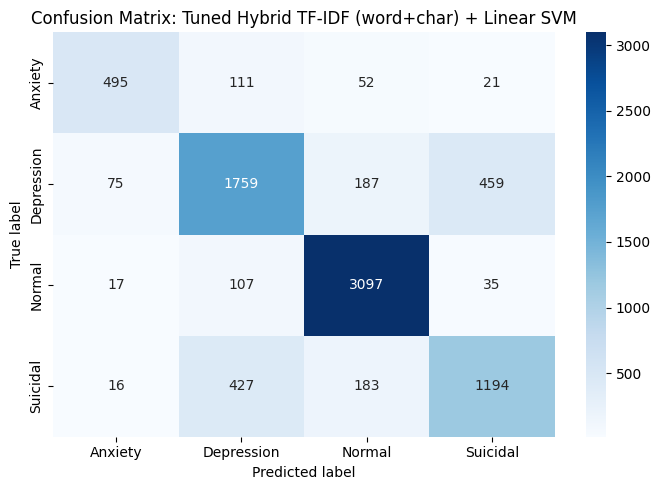

Suicidal one-vs-rest PR-AUC: 0.7252
Suicidal Average Precision:  0.7255


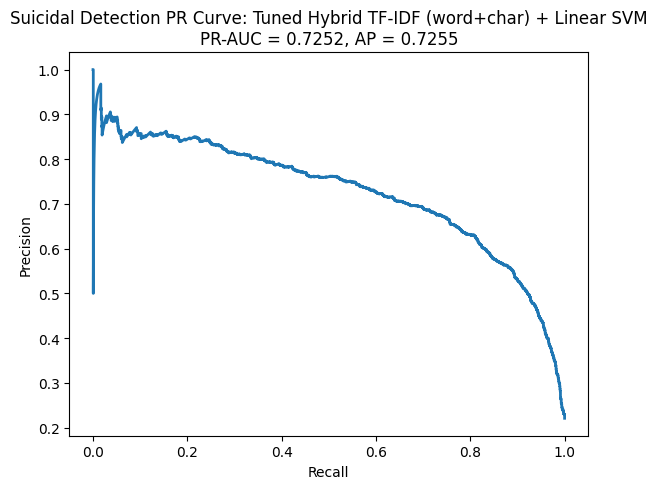

In [15]:
# 4. Model: Tuned hybrid TF-IDF + SVM

tuned_hybrid_svm = grid_hybrid_svm.best_estimator_

res_best_hybrid_svm = evaluate_classifier(
    model_name="Tuned Hybrid TF-IDF (word+char) + Linear SVM",
    model=tuned_hybrid_svm,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

# Already used cross-validation on training data to find best regularization parameter above,
# so no need to evaluate again on CV.

### Best Model So Far
Using the best parameter, the **tuned hybrid TF-IDF + SVM** achieved:
- Accuracy: 0.7948
- Macro-F1: 0.7709
- Weighted-F1: 0.7916
- Suicidal PR-AUC: 0.7252

These results slightly improved upon the previous TF-IDF + SVM model, demonstrating that hyperparameter tuning helped find a better balance between model complexity and generalization.

# 5. Emsemble Best Models (non-transformer)

In [17]:
# Fit models on training split
tuned_hybrid_svm.fit(X_train_text, y_train)
hybrid_svm.fit(X_train_text, y_train)
tfidf_svm.fit(X_train_text, y_train)
tfidf_logreg.fit(X_train_text, y_train)

# Probabilities on validation split
p1 = tuned_hybrid_svm.predict_proba(X_val_text)
p2 = hybrid_svm.predict_proba(X_val_text)
p3 = tfidf_svm.predict_proba(X_val_text)
p4 = tfidf_logreg.predict_proba(X_val_text)

# Weighted ensemble
ensemble_probs = (
    0.40 * p1 +
    0.25 * p2 +
    0.20 * p3 +
    0.15 * p4
)

ensemble_pred = ensemble_probs.argmax(axis=1)

print("Ensemble accuracy:", accuracy_score(y_val, ensemble_pred))
print("Ensemble macro F1:", f1_score(y_val, ensemble_pred, average="macro"))
print("Ensemble weighted F1:", f1_score(y_val, ensemble_pred, average="weighted"))

Ensemble accuracy: 0.8002428658166363
Ensemble macro F1: 0.7769917463010214
Ensemble weighted F1: 0.7976067097190218


In [18]:
# Fit models on full labeled dataset
tuned_hybrid_svm.fit(X_text_all, y_all)
hybrid_svm.fit(X_text_all, y_all)
tfidf_svm.fit(X_text_all, y_all)
tfidf_logreg.fit(X_text_all, y_all)

# Get probabilities on Kaggle test set
p1 = tuned_hybrid_svm.predict_proba(test_df["clean_text_model"])
p2 = hybrid_svm.predict_proba(test_df["clean_text_model"])
p3 = tfidf_svm.predict_proba(test_df["clean_text_model"])
p4 = tfidf_logreg.predict_proba(test_df["clean_text_model"])

ensemble_probs = (
    0.40 * p1 +
    0.25 * p2 +
    0.20 * p3 +
    0.15 * p4
)

test_pred_int = ensemble_probs.argmax(axis=1)
test_pred_labels = label_encoder.inverse_transform(test_pred_int)

# save submission
sample_sub = pd.read_csv("sample_submission.csv")

sample_sub["status"] = test_pred_labels

submission_path = "submission_ensemble.csv"

sample_sub.to_csv(submission_path, index=False)

print("Saved:", submission_path)

display(sample_sub.head())

Saved: submission_ensemble.csv


,id,status
0,37716,Normal
1,17470,Suicidal
2,7630,Depression
3,9138,Suicidal
4,11713,Suicidal


# 6. Improvements with Feature Selection (ignore this)

In [ ]:
# Improved Model A: Hybrid TF-IDF + Chi-square Feature Selection + Logistic Regression

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression

hybrid_tfidf_logreg = Pipeline([
    ("features", FeatureUnion([
        ("word", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 3),
            min_df=3,
            max_df=0.90,
            sublinear_tf=True,
            strip_accents="unicode"
        )),
        ("char", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 6),
            min_df=3,
            sublinear_tf=True
        ))
    ])),
    ("select", SelectKBest(score_func=chi2, k=50000)),
    ("clf", LogisticRegression(
        C=4.0,
        solver="saga",
        max_iter=4000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

res_hybrid_tfidf_logreg = evaluate_classifier(
    model_name="Hybrid TF-IDF + Chi2 + Logistic Regression",
    model=hybrid_tfidf_logreg,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_hybrid_tfidf_logreg = cross_validate_model(
    model_name="Hybrid TF-IDF + Chi2 + Logistic Regression",
    model=hybrid_tfidf_logreg,
    X=X_text_all,
    y=y_all
)

In [ ]:
# Improved Model B: Hybrid TF-IDF + Chi-square Feature Selection + Calibrated Linear SVM

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

base_hybrid_tfidf_svm_fs = Pipeline([
    ("features", FeatureUnion([
        ("word", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 3),
            min_df=3,
            max_df=0.90,
            sublinear_tf=True,
            strip_accents="unicode"
        )),
        ("char", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 6),
            min_df=3,
            sublinear_tf=True
        ))
    ])),
    ("select", SelectKBest(score_func=chi2, k=50000)),
    ("svm", LinearSVC(
        C=0.5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

hybrid_tfidf_svm_fs = CalibratedClassifierCV(
    estimator=base_hybrid_tfidf_svm_fs,
    method="sigmoid",
    cv=3
)

res_hybrid_tfidf_svm_fs = evaluate_classifier(
    model_name="Hybrid TF-IDF + Chi2 + Calibrated Linear SVM",
    model=hybrid_tfidf_svm_fs,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_hybrid_tfidf_svm_fs = cross_validate_model(
    model_name="Hybrid TF-IDF + Chi2 + Calibrated Linear SVM",
    model=hybrid_tfidf_svm_fs,
    X=X_text_all,
    y=y_all
)

In [ ]:
# Grid search for Hybrid TF-IDF + Chi2 + Logistic Regression

from sklearn.model_selection import GridSearchCV

param_grid_logreg = {
    "clf__C": [0.5, 1, 2, 4, 8]
}

grid_hybrid_logreg = GridSearchCV(
    estimator=hybrid_tfidf_logreg,
    param_grid=param_grid_logreg,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_hybrid_logreg.fit(X_train_text, y_train)

print("Best params (logreg):", grid_hybrid_logreg.best_params_)
print("Best CV macro F1 (logreg):", grid_hybrid_logreg.best_score_)

best_hybrid_logreg = grid_hybrid_logreg.best_estimator_

res_best_hybrid_logreg = evaluate_classifier(
    model_name="Tuned Hybrid TF-IDF + Chi2 + Logistic Regression",
    model=best_hybrid_logreg,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

In [ ]:
# Grid search for Hybrid TF-IDF + Chi2 + Calibrated Linear SVM

param_grid_svm_fs = {
    "estimator__svm__C": [0.1, 0.25, 0.5, 1, 2]
}

grid_hybrid_svm_fs = GridSearchCV(
    estimator=hybrid_tfidf_svm_fs,
    param_grid=param_grid_svm_fs,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_hybrid_svm_fs.fit(X_train_text, y_train)

print("Best params (svm):", grid_hybrid_svm_fs.best_params_)
print("Best CV macro F1 (svm):", grid_hybrid_svm_fs.best_score_)

best_hybrid_svm_fs = grid_hybrid_svm_fs.best_estimator_

res_best_hybrid_svm_fs = evaluate_classifier(
    model_name="Tuned Hybrid TF-IDF + Chi2 + Calibrated Linear SVM",
    model=best_hybrid_svm_fs,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

# 5-2. Sentence Embedding Models

In [ ]:
# Feature Representation: Sentence embeddings
# SentenceTransformer creates dense semantic vectors for each post.
# This often helps when different posts express similar meaning with different words.

embedding_model_name = "all-MiniLM-L6-v2"
embedding_model = SentenceTransformer(embedding_model_name)

# Encode the labeled train data and unlabeled test data.
# convert_to_numpy=True returns standard NumPy arrays.
X_embed_all = embedding_model.encode(
    train_df["clean_text_model"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

X_embed_test = embedding_model.encode(
    test_df["clean_text_model"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

# Split embeddings using the same train/validation indices as before.
X_embed_train = X_embed_all[idx_train]
X_embed_val = X_embed_all[idx_val]

print("Embedding train shape:", X_embed_train.shape)
print("Embedding val shape:", X_embed_val.shape)
print("Embedding test shape:", X_embed_test.shape)

## 1. Sentence Embedding + LR

In [ ]:
# Model: Sentence Embeddings + Multinomial Logistic Regression

embed_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

res_embed_logreg = evaluate_classifier(
    model_name="Sentence Embeddings + Logistic Regression",
    model=embed_logreg,
    X_train=X_embed_train,
    y_train=y_train,
    X_val=X_embed_val,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_embed_logreg = cross_validate_model(
    model_name="Sentence Embeddings + Logistic Regression",
    model=embed_logreg,
    X=X_embed_all,
    y=y_all
)

## 2. Sentence Embedding + SVM

In [ ]:
# Model : Sentence Embeddings + Linear SVM

base_embed_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

embed_svm = CalibratedClassifierCV(
    estimator=base_embed_svm,
    method="sigmoid",
    cv=3
)

res_embed_svm = evaluate_classifier(
    model_name="Sentence Embeddings + Calibrated Linear SVM",
    model=embed_svm,
    X_train=X_embed_train,
    y_train=y_train,
    X_val=X_embed_val,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_embed_svm = cross_validate_model(
    model_name="Sentence Embeddings + Calibrated Linear SVM",
    model=embed_svm,
    X=X_embed_all,
    y=y_all
)

## 3. Enhanced SVM (now with linguistic features accounted)

In [ ]:
# Model: Embeddings + Linguistic Features + Linear SVM

base_combined_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

combined_svm = CalibratedClassifierCV(
    estimator=base_combined_svm,
    method="sigmoid",
    cv=3
)

res_combined_svm = evaluate_classifier(
    model_name="Embeddings + Linguistic Features + Calibrated Linear SVM",
    model=combined_svm,
    X_train=X_combined_train,
    y_train=y_train,
    X_val=X_combined_val,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_combined_svm = cross_validate_model(
    model_name="Embeddings + Linguistic Features + Calibrated Linear SVM",
    model=combined_svm,
    X=X_combined_all,
    y=y_all
)

### Parameter Tuning (Grid Search)

In [ ]:
# Hyperparameter tuning for Embeddings + Linguistic Features + SVM
#
# We tune the SVM regularization parameter C.
# This helps us choose the best balance between:
# - fitting the training data
# - generalizing well to unseen data
#
# We use macro F1 because:
# - this is a 4-class problem
# - the classes are imbalanced
# - we want balanced performance across classes

param_grid_combined_svm = {
    "estimator__svm__C": [0.1, 0.5, 1, 2, 5]
}

grid_combined_svm = GridSearchCV(
    estimator=combined_svm,
    param_grid=param_grid_combined_svm,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_combined_svm.fit(X_combined_train, y_train)

print("Best parameters found:")
print(grid_combined_svm.best_params_)

print("\nBest cross-validated macro F1:")
print(grid_combined_svm.best_score_)

## 4. Tuned SVM

In [ ]:
# Evaluate tuned Sentence Embeddings + Linguistic Features + SVM on the validation set
#
# Cross-validation was already integrated during grid search for hyperparameter tuning.

best_combined_svm = grid_combined_svm.best_estimator_

res_best_combined_svm = evaluate_classifier(
    model_name="Tuned Embeddings + Linguistic Features + Linear SVM",
    model=best_combined_svm,
    X_train=X_combined_train,
    y_train=y_train,
    X_val=X_combined_val,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

# 5-3. Transformer Model (DistilBERT)

In [20]:
from datasets import Dataset
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# prepare labels
label_encoder = LabelEncoder()
train_df["label"] = label_encoder.fit_transform(train_df["status"])

print("Label mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Label mapping:
0 -> Anxiety
1 -> Depression
2 -> Normal
3 -> Suicidal


In [ ]:
# Train/validation split
RANDOM_STATE = 42

bert_train_df, bert_val_df = train_test_split(
    train_df[["clean_text_model", "label"]].copy(),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_df["label"]
)

bert_train_df = bert_train_df.reset_index(drop=True)
bert_val_df = bert_val_df.reset_index(drop=True)

print("Train size:", bert_train_df.shape)
print("Validation size:", bert_val_df.shape)

Train size: (32939, 2)
Validation size: (8235, 2)


In [23]:
# Turns pandas DataFrames into the dataset format expected by Hugging Face
ds_train = Dataset.from_pandas(
    pd.DataFrame({
        "text": bert_train_df["clean_text_model"].values,
        "label": bert_train_df["label"].values
    }),
    preserve_index=False
)

ds_val = Dataset.from_pandas(
    pd.DataFrame({
        "text": bert_val_df["clean_text_model"].values,
        "label": bert_val_df["label"].values
    }),
    preserve_index=False
)

ds_test = Dataset.from_pandas(
    pd.DataFrame({
        "text": test_df["clean_text_model"].values
    }),
    preserve_index=False
)

In [24]:
# tokenizer
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

MAX_LENGTH = 128

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_train = ds_train.map(tokenize_batch, batched=True)
tokenized_val = ds_val.map(tokenize_batch, batched=True)
tokenized_test = ds_test.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map: 100%|██████████| 8436/8436 [00:00<00:00, 23904.24 examples/s]


In [25]:
# metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "macro_f1": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
        "weighted_f1": f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"],
        "macro_precision": precision_metric.compute(predictions=preds, references=labels, average="macro")["precision"],
        "macro_recall": recall_metric.compute(predictions=preds, references=labels, average="macro")["recall"],
    }

In [26]:
# load model
id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in enumerate(label_encoder.classes_)}

bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_encoder.classes_),
    id2label=id2label,
    label2id=label2id
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3117.19it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [27]:
# training arguments
training_args = TrainingArguments(
    output_dir="./distilbert_mental_health",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none"
)

In [29]:
# train once
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.563355,0.516918,0.810079,0.785344,0.808469,0.778224,0.794876
2,0.397626,0.509250,0.820036,0.799311,0.819105,0.803801,0.795380
3,0.298564,0.610707,0.816758,0.794530,0.816724,0.791638,0.798023


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.44it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=12354, training_loss=0.41984852807352374, metrics={'train_runtime': 9224.3195, 'train_samples_per_second': 10.713, 'train_steps_per_second': 1.339, 'total_flos': 3172133740594728.0, 'train_loss': 0.41984852807352374, 'epoch': 3.0})

In [30]:
# Validation evaluation
bert_pred_output = trainer.predict(tokenized_val)

bert_logits = bert_pred_output.predictions
bert_y_true = bert_pred_output.label_ids
bert_y_pred = np.argmax(bert_logits, axis=1)

print(classification_report(
    bert_y_true,
    bert_y_pred,
    target_names=label_encoder.classes_,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

     Anxiety     0.8224    0.7776    0.7994       679
  Depression     0.7641    0.7367    0.7502      2480
      Normal     0.9219    0.9496    0.9356      3256
    Suicidal     0.7073    0.7181    0.7126      1820

    accuracy                         0.8202      8235
   macro avg     0.8039    0.7955    0.7994      8235
weighted avg     0.8187    0.8202    0.8192      8235



In [32]:
# Final kaggle submission
full_train_df = train_df[["clean_text_model", "label"]].copy()

ds_full = Dataset.from_pandas(
    pd.DataFrame({
        "text": full_train_df["clean_text_model"].values,
        "label": full_train_df["label"].values
    }),
    preserve_index=False
)

ds_test = Dataset.from_pandas(
    pd.DataFrame({
        "text": test_df["clean_text_model"].values
    }),
    preserve_index=False
)

tokenized_full = ds_full.map(tokenize_batch, batched=True)
tokenized_test = ds_test.map(tokenize_batch, batched=True)

final_model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_encoder.classes_),
    id2label=id2label,
    label2id=label2id
)

final_args = TrainingArguments(
    output_dir="./distilbert_full_train",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="no",
    logging_strategy="epoch",
    report_to="none"
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=tokenized_full,
    data_collator=data_collator
)

final_trainer.train()

test_outputs = final_trainer.predict(tokenized_test)
test_logits = test_outputs.predictions
test_pred_int = np.argmax(test_logits, axis=1)
test_pred_labels = label_encoder.inverse_transform(test_pred_int)

sample_sub = pd.read_csv("sample_submission.csv")
sample_sub.iloc[:, 1] = test_pred_labels

submission_path = "submission_distilbert.csv"
sample_sub.to_csv(submission_path, index=False)

print("Saved:", submission_path)
display(sample_sub.head())

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7009.20it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
5147,0.559942
10294,0.398104
15441,0.304676


Saved: submission_distilbert.csv


,id,status
0,37716,Normal
1,17470,Suicidal
2,7630,Depression
3,9138,Suicidal
4,11713,Suicidal


# 5-4. Optional: RF, kNN

MODEL: Sentence Embeddings + Random Forest (optional)
Accuracy:      0.7467
Macro F1:      0.7034
Weighted F1:   0.7379
Macro Prec.:   0.7431
Macro Recall:  0.6827

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.7946    0.5641    0.6598       679
  Depression     0.6524    0.6871    0.6693      2480
      Normal     0.8209    0.9533    0.8822      3256
    Suicidal     0.7044    0.5264    0.6025      1820

    accuracy                         0.7467      8235
   macro avg     0.7431    0.6827    0.7034      8235
weighted avg     0.7423    0.7467    0.7379      8235



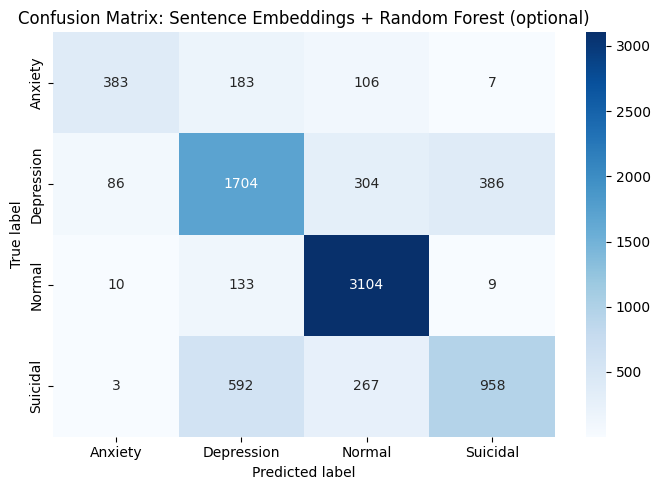

Suicidal one-vs-rest PR-AUC: 0.6569
Suicidal Average Precision:  0.6574


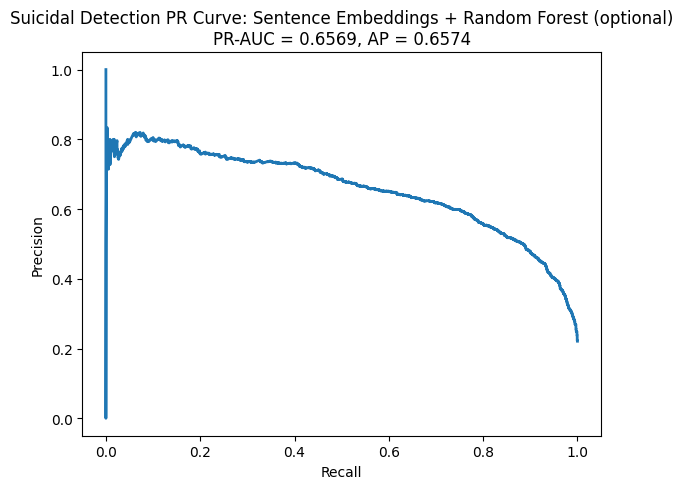

MODEL: Sentence Embeddings + kNN (optional)
Accuracy:      0.7728
Macro F1:      0.7417
Weighted F1:   0.7710
Macro Prec.:   0.7464
Macro Recall:  0.7377

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.7395    0.7025    0.7205       679
  Depression     0.6875    0.6883    0.6879      2480
      Normal     0.9013    0.9340    0.9173      3256
    Suicidal     0.6572    0.6258    0.6411      1820

    accuracy                         0.7728      8235
   macro avg     0.7464    0.7377    0.7417      8235
weighted avg     0.7696    0.7728    0.7710      8235



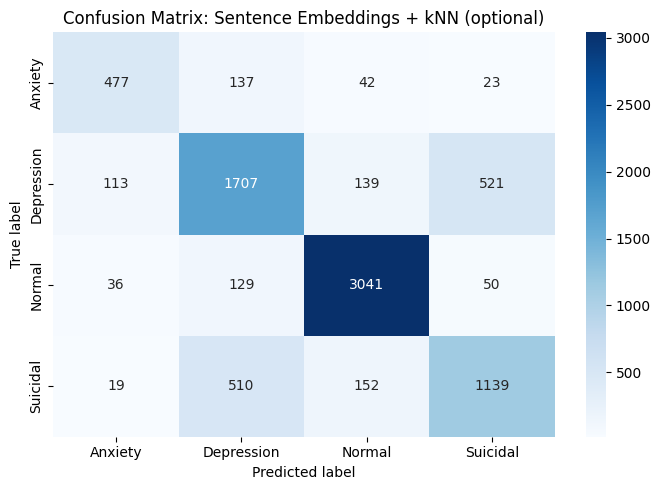

Suicidal one-vs-rest PR-AUC: 0.6766
Suicidal Average Precision:  0.6749


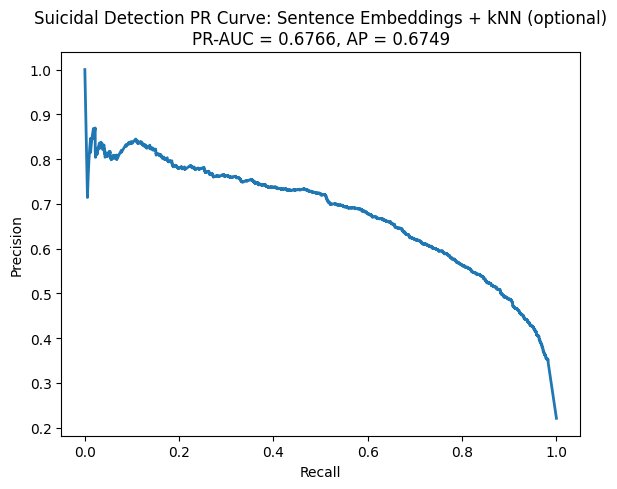

In [ ]:
# Optional comparison models
#
# Why not?
# - Random Forest is not usually ideal for dense high-dimensional embeddings
# - kNN often suffers in high-dimensional spaces
#
# So treat these as optional benchmark comparisons.

RUN_OPTIONAL_MODELS = True

optional_results = []

if RUN_OPTIONAL_MODELS:
    # Random Forest
    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    res_rf = evaluate_classifier(
        model_name="Sentence Embeddings + Random Forest (optional)",
        model=rf_model,
        X_train=X_embed_train,
        y_train=y_train,
        X_val=X_embed_val,
        y_val=y_val,
        class_names=label_encoder.classes_,
        has_predict_proba=True
    )
    optional_results.append(res_rf)

    # kNN
    knn_model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(
            n_neighbors=15,
            weights="distance",
            metric="cosine"
        ))
    ])

    res_knn = evaluate_classifier(
        model_name="Sentence Embeddings + kNN (optional)",
        model=knn_model,
        X_train=X_embed_train,
        y_train=y_train,
        X_val=X_embed_val,
        y_val=y_val,
        class_names=label_encoder.classes_,
        has_predict_proba=True
    )
    optional_results.append(res_knn)

# 6. Total Results

In [ ]:
# Validation results table

all_results = [
    res_tfidf_logreg,
    res_tfidf_svm,
    res_hybrid_svm,
    res_best_hybrid_svm,
    res_embed_logreg,
    res_embed_svm,
    res_combined_svm,
    res_best_combined_svm,
]

if RUN_OPTIONAL_MODELS:
    all_results.extend(optional_results)

results_df = pd.DataFrame(all_results)

# Sort mainly by macro F1, then suicidal PR-AUC, then accuracy
sort_cols = [c for c in ["macro_f1", "suicidal_pr_auc", "accuracy"] if c in results_df.columns]
results_df = results_df.sort_values(sort_cols, ascending=False).reset_index(drop=True)

display(results_df)


,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,suicidal_pr_auc,suicidal_average_precision
0,Hybrid TF-IDF (word+char) + Linear SVM,0.797086,0.773074,0.794332,0.788879,0.760773,0.722458,0.722725
1,Tuned Hybrid TF-IDF (word+char) + Linear SVM,0.794778,0.770866,0.791627,0.782832,0.761375,0.725236,0.725522
2,TF-IDF + Calibrated Linear SVM,0.792471,0.767362,0.789422,0.785877,0.753462,0.723203,0.723410
3,TF-IDF + Multinomial Logistic Regression,0.786400,0.763175,0.785203,0.755260,0.773881,0.716606,0.716800
4,Embeddings + Linguistic Features + Calibrated ...,0.785914,0.752990,0.782848,0.767563,0.741774,0.705526,0.705851
5,Tuned Embeddings + Linguistic Features + Linea...,0.785914,0.752911,0.782847,0.767312,0.741810,0.705510,0.705835
6,Sentence Embeddings + Calibrated Linear SVM,0.780571,0.748321,0.777443,0.761572,0.738002,0.697369,0.697730
7,Sentence Embeddings + kNN (optional),0.772799,0.741732,0.770976,0.746389,0.737651,0.676563,0.674940
8,Sentence Embeddings + Logistic Regression,0.768306,0.736432,0.768497,0.721908,0.767722,0.695743,0.695998
9,Sentence Embeddings + Random Forest (optional),0.746691,0.703443,0.737926,0.743085,0.682713,0.656872,0.657399


In [ ]:
# Cross-validation results table
#
# Note:
# - For tuned models, the cross-validated macro F1 was already computed inside GridSearchCV.
# - We record that best CV score directly instead of running a second CV loop immediately.

cv_results_rows = [
    cv_tfidf_logreg,
    cv_tfidf_svm,
    cv_hybrid_svm,
    {
        "model": "Tuned Hybrid TF-IDF (word+char) + Linear SVM",
        "cv_accuracy_mean": np.nan,
        "cv_accuracy_std": np.nan,
        "cv_macro_f1_mean": grid_hybrid_svm.best_score_,
        "cv_macro_f1_std": np.nan,
        "cv_weighted_f1_mean": np.nan,
        "cv_weighted_f1_std": np.nan,
        "best_C": grid_hybrid_svm.best_params_["estimator__svm__C"]
    },
    cv_embed_logreg,
    cv_embed_svm,
    cv_combined_svm,
    {
        "model": "Tuned Embeddings + Linguistic Features + Linear SVM",
        "cv_accuracy_mean": np.nan,
        "cv_accuracy_std": np.nan,
        "cv_macro_f1_mean": grid_combined_svm.best_score_,
        "cv_macro_f1_std": np.nan,
        "cv_weighted_f1_mean": np.nan,
        "cv_weighted_f1_std": np.nan,
        "best_C": grid_combined_svm.best_params_["estimator__svm__C"]
    }
]

cv_results_df = pd.DataFrame(cv_results_rows)

cv_results_df = cv_results_df.sort_values(
    by=["cv_macro_f1_mean", "cv_accuracy_mean"],
    ascending=False,
    na_position="last"
).reset_index(drop=True)

display(cv_results_df)


,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,cv_weighted_f1_std,best_C
0,Hybrid TF-IDF (word+char) + Linear SVM,0.797178,0.003527,0.772066,0.003572,0.794478,0.003426,NaN
1,Tuned Hybrid TF-IDF (word+char) + Linear SVM,NaN,NaN,0.769229,NaN,NaN,NaN,0.1
2,TF-IDF + Calibrated Linear SVM,0.793146,0.003069,0.767220,0.003953,0.789985,0.003138,NaN
3,TF-IDF + Multinomial Logistic Regression,0.787924,0.005137,0.763944,0.005298,0.786732,0.005062,NaN
4,Embeddings + Linguistic Features + Calibrated ...,0.781051,0.005852,0.747502,0.007360,0.778232,0.005946,NaN
5,Tuned Embeddings + Linguistic Features + Linea...,NaN,NaN,0.742352,NaN,NaN,NaN,2.0
6,Sentence Embeddings + Calibrated Linear SVM,0.775878,0.005012,0.742126,0.006673,0.772842,0.005084,NaN
7,Sentence Embeddings + Logistic Regression,0.765896,0.003940,0.734105,0.004351,0.766141,0.004008,NaN


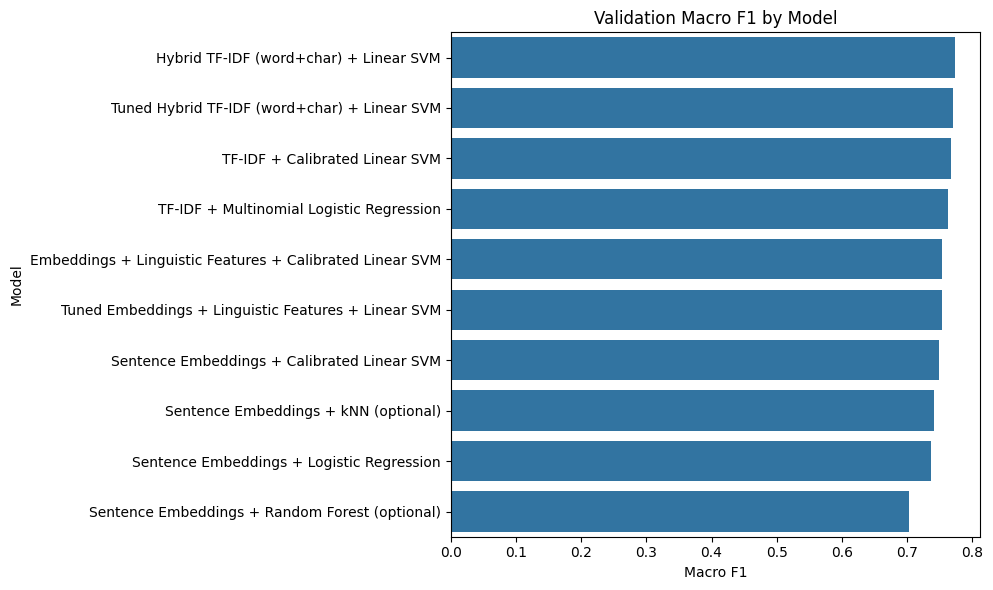

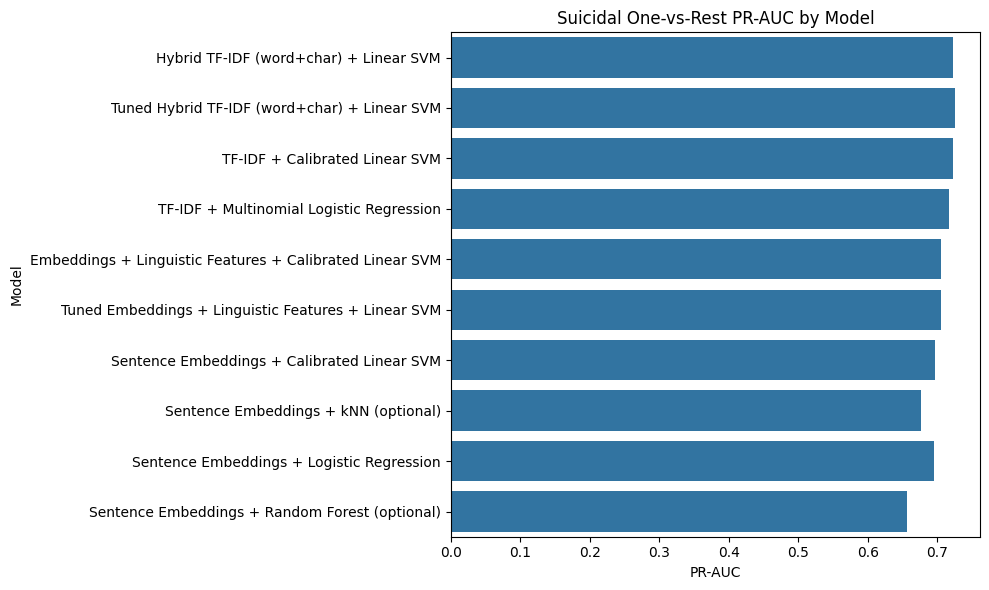

In [32]:
# Plot model comparison for report figures

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="macro_f1", y="model")
plt.title("Validation Macro F1 by Model")
plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

if "suicidal_pr_auc" in results_df.columns:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=results_df, x="suicidal_pr_auc", y="model")
    plt.title("Suicidal One-vs-Rest PR-AUC by Model")
    plt.xlabel("PR-AUC")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()

In [34]:
# Choose the best model for final training
#
# Recommendation:
# - If a model wins on macro F1 and also has strong suicidal PR-AUC,
#   prefer that one.
# - In many text tasks, the best practical model is often either:
#   * TF-IDF + calibrated linear SVM
#   * embeddings + logistic regression
#   * embeddings + features + logistic regression
#
# Edit BEST_MODEL_NAME if results suggest a different winner.

BEST_MODEL_NAME = results_df.loc[0, "model"]
print("Best validation model selected:", BEST_MODEL_NAME)

Best validation model selected: Hybrid TF-IDF (word+char) + Linear SVM


# 7. Best Model

## Retrain on Full Labeled Data

In [ ]:
# Refit the best model on the full labeled training data
# We use all labeled rows now because model selection is already done
tuned_hybrid_svm.fit(X_text_all, y_all)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('word', ...), ('char', ...)]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to 

In [ ]:
# Predict on the test set
# Use the same cleaned text column that the model was trained on.
test_pred_int = tuned_hybrid_svm.predict(test_df["clean_text_model"])

# Convert integer predictions back to original class labels
test_pred_labels = label_encoder.inverse_transform(test_pred_int)

# Load the sample submission file to match Kaggle's required format
sample_sub = pd.read_csv("sample_submission.csv")

print("Sample submission columns:", list(sample_sub.columns))
print("Sample submission shape:", sample_sub.shape)
print("Test shape:", test_df.shape)

# Fill the prediction column
# Assumes the label column is named 'status', which matches your competition files.
sample_sub["status"] = test_pred_labels

# Save the final submission file
submission_path = "submission_tuned_hybrid_svm.csv"
sample_sub.to_csv(submission_path, index=False)

# Preview the file before uploading
print(f"\nSaved submission file to: {submission_path}")
display(sample_sub.head())
print("Final submission shape:", sample_sub.shape)
print("\nPredicted class distribution:")
print(sample_sub["status"].value_counts())

Sample submission columns: ['id', 'status']
Sample submission shape: (8436, 2)
Test shape: (8436, 3)

Saved submission file to: submission_tuned_hybrid_svm.csv


,id,status
0,37716,Normal
1,17470,Suicidal
2,7630,Depression
3,9138,Suicidal
4,11713,Suicidal


Final submission shape: (8436, 2)

Predicted class distribution:
status
Normal        2575
Depression    2340
Suicidal      1832
Anxiety       1689
Name: count, dtype: int64


# 8. Extension to Risk Detection

In [45]:
# Predicted probabilities from tuned hybrid TF-IDF + SVM

# Predicted 4-class probabilities on validation data
hybrid_val_proba = tuned_hybrid_svm.predict_proba(X_val_text)

# Predicted class labels
hybrid_val_pred = tuned_hybrid_svm.predict(X_val_text)

# Class names in the same order as probability columns
hybrid_class_names = label_encoder.classes_

print("Class order:", hybrid_class_names)
print("Probability matrix shape:", hybrid_val_proba.shape)

Class order: ['Anxiety' 'Depression' 'Normal' 'Suicidal']
Probability matrix shape: (8235, 4)


In [ ]:
# Construct weighted risk score

# Map class names to probability column indices
class_to_idx = {cls: i for i, cls in enumerate(hybrid_class_names)}

idx_suicidal = class_to_idx["Suicidal"]
idx_depression = class_to_idx["Depression"]
idx_anxiety = class_to_idx["Anxiety"]

# Single risk score for each post with different weights across classes
# Suicidal class has the highest weight since it is considered to be highest risk
# Normal class is baseline class with weight of 0
hybrid_risk_score = (
    1.0 * hybrid_val_proba[:, idx_suicidal] +
    0.6 * hybrid_val_proba[:, idx_depression] +
    0.4 * hybrid_val_proba[:, idx_anxiety]
)

# Example risk scores
print("First 10 risk scores:")
print(hybrid_risk_score[:10])

First 10 risk scores:
[0.4254477  0.21774698 0.78496476 0.03996661 0.62752172 0.63903773
 0.94405665 0.04601108 0.40982594 0.17924071]


In [ ]:
# If y_val is encoded as integers, decode it back to labels first
if np.issubdtype(np.array(y_val).dtype, np.integer):
    y_val_labels = label_encoder.inverse_transform(np.array(y_val))
else:
    y_val_labels = np.array(y_val)

# **Ground truth**: We simplify 4 classes into 2 categories (1 for Suicidal or Depression, 0 for Anxiety or Normal)
high_risk_true = np.isin(y_val_labels, ["Suicidal", "Depression"]).astype(int)

# Threshold for flagging
risk_threshold = 0.50

# If risk score >= 0.50, then flag = 1 (passed onto human moderators to review), flag = 0 otherwise
high_risk_flag = (hybrid_risk_score >= risk_threshold).astype(int)

print("Number flagged for review:", high_risk_flag.sum())
print("Proportion flagged:", high_risk_flag.mean())

Number flagged for review: 4088
Proportion flagged: 0.49641772920461447


In [48]:
# Metrics evaluate how well the model identifies high-risk posts

print("High-risk screening results")
print("Accuracy: ", accuracy_score(high_risk_true, high_risk_flag))
print("Precision:", precision_score(high_risk_true, high_risk_flag, zero_division=0))
print("Recall:   ", recall_score(high_risk_true, high_risk_flag, zero_division=0))
print("F1-score: ", f1_score(high_risk_true, high_risk_flag, zero_division=0))

cm = confusion_matrix(high_risk_true, high_risk_flag)
print("\nConfusion matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print("\nFalse negative rate:", false_negative_rate)
print("False positive rate:", false_positive_rate)

High-risk screening results
Accuracy:  0.9278688524590164
Precision: 0.9532778864970646
Recall:    0.9062790697674419
F1-score:  0.9291845493562232

Confusion matrix:
[[3744  191]
 [ 403 3897]]

False negative rate: 0.09372093023255813
False positive rate: 0.048538754764930116


In [ ]:
# Summary table

screening_summary = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Proportion Flagged",
        "High-Risk Precision",
        "High-Risk Recall",
        "High-Risk F1",
        "False Negative Rate",
        "False Positive Rate"
    ],
    "Value": [
        risk_threshold,
        high_risk_flag.mean(),
        precision_score(high_risk_true, high_risk_flag, zero_division=0),
        recall_score(high_risk_true, high_risk_flag, zero_division=0),
        f1_score(high_risk_true, high_risk_flag, zero_division=0),
        false_negative_rate,
        false_positive_rate
    ]
})

screening_summary

,Metric,Value
0,Threshold,0.500000
1,Proportion Flagged,0.496418
2,High-Risk Precision,0.953278
3,High-Risk Recall,0.906279
4,High-Risk F1,0.929185
5,False Negative Rate,0.093721
6,False Positive Rate,0.048539


In [47]:
#  Some Examples: actual posts flagged as high risk

val_results = pd.DataFrame({
    "text": X_val_text.reset_index(drop=True) if hasattr(X_val_text, "reset_index") else pd.Series(X_val_text),
    "true_label": y_val_labels,
    "predicted_label": label_encoder.inverse_transform(hybrid_val_pred),
    "risk_score": hybrid_risk_score,
    "flagged_for_review": high_risk_flag
})

# Sort by highest risk score
flagged_examples = val_results[val_results["flagged_for_review"] == 1] \
    .sort_values("risk_score", ascending=False)

flagged_examples.head(10)

,text,true_label,predicted_label,risk_score,flagged_for_review
7861,i just lost a friend of my suicidal thoughts a...,Suicidal,Suicidal,0.992765,1
6305,i cannot live on this earth anymore i just wan...,Suicidal,Suicidal,0.988877,1
1579,my only friend left me out of no where he told...,Suicidal,Suicidal,0.988416,1
3759,i want to kill myself i am so fucking done,Suicidal,Suicidal,0.988269,1
374,i am really scared i am going to do something ...,Suicidal,Suicidal,0.985830,1
3090,i do not know what to really type here i guess...,Suicidal,Suicidal,0.985725,1
5484,i have been suicidal for the past 3 weeks i do...,Depression,Suicidal,0.983660,1
2907,as a religious person my religion is buddhism ...,Suicidal,Suicidal,0.981679,1
5619,i have no access to any tall buildings guns an...,Suicidal,Suicidal,0.981571,1
4636,so i have decided that i am going to do it bei...,Suicidal,Suicidal,0.981512,1


In [ ]:
# False negatives: Missed high-risk posts (actually high riks, but not flagged)

missed_high_risk = val_results[
    (np.isin(val_results["true_label"], ["Suicidal", "Depression"])) &
    (val_results["flagged_for_review"] == 0)
].sort_values("risk_score", ascending=True)

print("Number of missed high-risk posts:", len(missed_high_risk))
missed_high_risk.head(10)

Number of missed high-risk posts: 403


,text,true_label,predicted_label,risk_score,flagged_for_review
7908,ahh,Depression,2,0.044326,0
7654,same story different girl,Depression,2,0.063385,0
3642,it is sickening what is sickening is we elect ...,Suicidal,2,0.095581,0
1970,my heart is so crushed,Suicidal,2,0.095616,0
4471,can you? did not sink so you can ban me once c...,Depression,2,0.105943,0
3515,tfw it is 5pm and you still have not got out o...,Depression,2,0.116121,0
7567,bliss peace rest ease solidified finite,Depression,2,0.123184,0
2789,lol you all should be glad,Suicidal,2,0.124934,0
4987,that guy is the total complete product of prog...,Suicidal,2,0.132762,0
2842,it s kind of funny isn t it,Depression,2,0.136459,0


# 9. Statistical Inference

## Bootstrap CI & Hypothesis Testing

In [64]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from scipy.stats import chi2

# Statistical analysis for:
# 1) tuned_hybrid_svm
# 2) DistilBERT

!pip install statsmodels
from statsmodels.stats.contingency_tables import mcnemar

# 1. Get validation predictions
# Tuned hybrid SVM on validation split
svm_val_pred = tuned_hybrid_svm.predict(X_val_text)
svm_val_proba = tuned_hybrid_svm.predict_proba(X_val_text)

# DistilBERT on validation split
bert_pred_output = trainer.predict(tokenized_val)
bert_logits = bert_pred_output.predictions
bert_y_true = bert_pred_output.label_ids

# Stable softmax for logits -> probabilities
def softmax_numpy(x):
    x = np.asarray(x)
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

bert_val_proba = softmax_numpy(bert_logits)
bert_val_pred = np.argmax(bert_val_proba, axis=1)


# 2. Bootstrap confidence intervals
def stratified_bootstrap_metric(
    y_true,
    y_pred,
    y_prob=None,
    metric="weighted_f1",
    n_boot=1000,
    random_state=42
):
    """
    Bootstrap mean and 95% CI for a metric.

    Supported metrics:
    - accuracy
    - macro_f1
    - weighted_f1
    - multiclass_auc
    """
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_prob is not None:
        y_prob = np.asarray(y_prob)

    n = len(y_true)
    scores = []

    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)

        y_true_b = y_true[idx]
        y_pred_b = y_pred[idx]

        try:
            if metric == "accuracy":
                score = accuracy_score(y_true_b, y_pred_b)

            elif metric == "macro_f1":
                score = f1_score(y_true_b, y_pred_b, average="macro")

            elif metric == "weighted_f1":
                score = f1_score(y_true_b, y_pred_b, average="weighted")

            elif metric == "multiclass_auc":
                # Need probabilities and at least 2 classes in the bootstrap sample
                if y_prob is None:
                    raise ValueError("y_prob is required for multiclass_auc")

                y_prob_b = y_prob[idx]

                # roc_auc_score can fail if some classes are missing in a resample
                if len(np.unique(y_true_b)) < len(np.unique(y_true)):
                    continue

                score = roc_auc_score(
                    y_true_b,
                    y_prob_b,
                    multi_class="ovr",
                    average="weighted"
                )
            else:
                raise ValueError(f"Unsupported metric: {metric}")

            scores.append(score)

        except Exception:
            continue

    if len(scores) == 0:
        raise ValueError(f"No valid bootstrap samples for metric={metric}")

    scores = np.array(scores)
    mean_score = scores.mean()
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    return mean_score, (lower, upper)


# 3. Compute bootstrap CIs for both models
results = []

for model_name, y_pred, y_prob in [
    ("Tuned Hybrid SVM", svm_val_pred, svm_val_proba),
    ("DistilBERT", bert_val_pred, bert_val_proba),
]:
    acc_mean, acc_ci = stratified_bootstrap_metric(y_val, y_pred, metric="accuracy")
    macro_f1_mean, macro_f1_ci = stratified_bootstrap_metric(y_val, y_pred, metric="macro_f1")
    weighted_f1_mean, weighted_f1_ci = stratified_bootstrap_metric(y_val, y_pred, metric="weighted_f1")
    auc_mean, auc_ci = stratified_bootstrap_metric(y_val, y_pred, y_prob=y_prob, metric="multiclass_auc")

    results.append({
        "Model": model_name,
        "Accuracy": round(acc_mean, 4),
        "Accuracy 95% CI": f"({acc_ci[0]:.4f}, {acc_ci[1]:.4f})",
        "Macro F1": round(macro_f1_mean, 4),
        "Macro F1 95% CI": f"({macro_f1_ci[0]:.4f}, {macro_f1_ci[1]:.4f})",
        "Weighted F1": round(weighted_f1_mean, 4),
        "Weighted F1 95% CI": f"({weighted_f1_ci[0]:.4f}, {weighted_f1_ci[1]:.4f})",
        "Weighted OvR AUC": round(auc_mean, 4),
        "Weighted OvR AUC 95% CI": f"({auc_ci[0]:.4f}, {auc_ci[1]:.4f})",
    })

results_df = pd.DataFrame(results)
display(results_df)


# 4. McNemar test: are the two models significantly different?
# Must compare on the SAME validation examples
svm_correct = (svm_val_pred == y_val)
bert_correct = (bert_val_pred == y_val)

# Table layout:
#                BERT correct   BERT wrong
# SVM correct        a             b
# SVM wrong          c             d
a = np.sum((svm_correct == True)  & (bert_correct == True))
b = np.sum((svm_correct == True)  & (bert_correct == False))
c = np.sum((svm_correct == False) & (bert_correct == True))
d = np.sum((svm_correct == False) & (bert_correct == False))

mcnemar_table = [[a, b],
                 [c, d]]

print("McNemar contingency table:")
print(pd.DataFrame(
    mcnemar_table,
    index=["SVM correct", "SVM wrong"],
    columns=["BERT correct", "BERT wrong"]
))

mcnemar_result = mcnemar(mcnemar_table, exact=True)

print("\nMcNemar test statistic:", mcnemar_result.statistic)
print("McNemar p-value:", mcnemar_result.pvalue)

if mcnemar_result.pvalue < 0.05:
    print("Conclusion: The two models differ significantly on validation accuracy.")
else:
    print("Conclusion: The difference in validation accuracy is not statistically significant.")


# 5. Optional: quick summary printout
print("\nValidation summary:")
print(f"SVM accuracy:  {accuracy_score(y_val, svm_val_pred):.4f}")
print(f"BERT accuracy: {accuracy_score(y_val, bert_val_pred):.4f}")

print(f"SVM macro F1:  {f1_score(y_val, svm_val_pred, average='macro'):.4f}")
print(f"BERT macro F1: {f1_score(y_val, bert_val_pred, average='macro'):.4f}")

print(f"SVM weighted F1:  {f1_score(y_val, svm_val_pred, average='weighted'):.4f}")
print(f"BERT weighted F1: {f1_score(y_val, bert_val_pred, average='weighted'):.4f}")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Seyoung\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


,Model,Accuracy,Accuracy 95% CI,Macro F1,Macro F1 95% CI,Weighted F1,Weighted F1 95% CI,Weighted OvR AUC,Weighted OvR AUC 95% CI
0,Tuned Hybrid SVM,0.8753,"(0.8682, 0.8831)",0.8679,"(0.8597, 0.8764)",0.8741,"(0.8669, 0.8820)",0.9743,"(0.9718, 0.9766)"
1,DistilBERT,0.8203,"(0.8117, 0.8290)",0.7995,"(0.7898, 0.8093)",0.8193,"(0.8107, 0.8283)",0.9524,"(0.9489, 0.9560)"


McNemar contingency table:
             BERT correct  BERT wrong
SVM correct          6476         732
SVM wrong             278         749

McNemar test statistic: 278.0
McNemar p-value: 1.0320608833261919e-47
Conclusion: The two models differ significantly on validation accuracy.

Validation summary:
SVM accuracy:  0.8753
BERT accuracy: 0.8202
SVM macro F1:  0.8679
BERT macro F1: 0.7994
SVM weighted F1:  0.8741
BERT weighted F1: 0.8192


# 10. Interpretability: SHAP

## SVM

In [ ]:
import shap

# Rebuild explainable SVM
# we want SHAP to explain text features and not calibration function
# our current SVM model: text -> TF-IDF -> SVM weights -> class prediction
# but we want: text -> TF-IDF -> calibration sigmoid -> probability
# so we "un"calibrate trained SVM so that SHAP explains SVM score with features and not probability with features
best_C = grid_hybrid_svm.best_params_["estimator__svm__C"]

word_tfidf_shap = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

char_tfidf_shap = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=3,
    sublinear_tf=True
)

hybrid_tfidf_shap = FeatureUnion([
    ("word", word_tfidf_shap),
    ("char", char_tfidf_shap)
])

svm_for_shap = Pipeline([
    ("features", hybrid_tfidf_shap),
    ("svm", LinearSVC(
        C=best_C,
        class_weight="balanced",
        random_state=42
    ))
])

svm_for_shap.fit(X_train_text, y_train)


# 2. Transform text
X_train_sparse = svm_for_shap.named_steps["features"].transform(X_train_text)
X_val_sparse = svm_for_shap.named_steps["features"].transform(X_val_text)

feature_names = svm_for_shap.named_steps["features"].get_feature_names_out()
linear_svm = svm_for_shap.named_steps["svm"]
class_names = list(label_encoder.classes_)

print("Train shape:", X_train_sparse.shape)
print("Val shape:", X_val_sparse.shape)
print("Classes:", class_names)


# 3. Background sample
rng = np.random.default_rng(42)
background_size = min(1000, X_train_sparse.shape[0])
background_idx = rng.choice(X_train_sparse.shape[0], size=background_size, replace=False)
X_background = X_train_sparse[background_idx]

# 4. Build SHAP explainer
svm_explainer = shap.LinearExplainer(linear_svm, X_background)

sample_size = min(300, X_val_sparse.shape[0])
X_val_sample = X_val_sparse[:sample_size]

svm_shap_raw = svm_explainer.shap_values(X_val_sample)

# Normalize output shape to (n_samples, n_features, n_classes)
if isinstance(svm_shap_raw, list):
    svm_shap_values = np.stack(svm_shap_raw, axis=-1)
else:
    svm_shap_values = np.asarray(svm_shap_raw)
    if svm_shap_values.ndim == 2:
        svm_shap_values = svm_shap_values[:, :, np.newaxis]

print("SHAP shape:", svm_shap_values.shape)

Train shape: (32939, 168252)
Val shape: (8235, 168252)
Classes: ['Anxiety', 'Depression', 'Normal', 'Suicidal']
SHAP shape: (300, 168252, 4)


In [67]:
# Global SHAP tables for SVM
svm_global_tables = {}

for class_idx, class_name in enumerate(class_names):
    mean_abs_shap = np.abs(svm_shap_values[:, :, class_idx]).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:20]

    top_df = pd.DataFrame({
        "feature": feature_names[top_idx],
        "mean_abs_shap": mean_abs_shap[top_idx]
    })

    svm_global_tables[class_name] = top_df

    print(f"\nTop SHAP features for class: {class_name}")
    display(top_df)


Top SHAP features for class: Anxiety


,feature,mean_abs_shap
0,word__it is,0.019757
1,word__anxiety,0.016566
2,word__and,0.013445
3,word__am,0.013381
4,char__ m,0.013184
5,word__wa,0.012834
6,word__depression,0.011079
7,char__ anx,0.009756
8,char__anx,0.009749
9,char__nxi,0.009606



Top SHAP features for class: Depression


,feature,mean_abs_shap
0,word__depression,0.031086
1,char__ i,0.024847
2,char__ an,0.016259
3,word__it is,0.014241
4,char__ m,0.013354
5,word__and,0.012983
6,char__ de,0.012260
7,word__to,0.011254
8,word__feel,0.010326
9,char__depre,0.009273



Top SHAP features for class: Normal


,feature,mean_abs_shap
0,word__depression,0.027388
1,char__ i,0.017451
2,word__am,0.017043
3,word__and,0.015142
4,char__ de,0.015084
5,char__ an,0.013320
6,word__feel,0.012612
7,word__me,0.012222
8,word__life,0.011508
9,word__myself,0.010874



Top SHAP features for class: Suicidal


,feature,mean_abs_shap
0,word__am,0.013684
1,char__ i,0.012979
2,word__here,0.010311
3,word__die,0.010057
4,word__wa,0.009741
5,char__ t,0.008657
6,word__myself,0.008550
7,word__it is,0.008397
8,word__to,0.007963
9,char__ing,0.007891


## BERT

In [68]:
# SHAP text masker
bert_masker = shap.maskers.Text(tokenizer)

# Explainer for DistilBERT probabilities
bert_explainer = shap.Explainer(
    distilbert_predict_proba,
    bert_masker,
    output_names=list(label_encoder.classes_)
)

# small subset because this is much slower than SVM SHAP
bert_text_sample = list(
    X_val_text.iloc[:5] if hasattr(X_val_text, "iloc") else X_val_text[:5]
)

bert_shap_values = bert_explainer(bert_text_sample)

print("Computed SHAP for", len(bert_text_sample), "texts")

PartitionExplainer explainer: 6it [00:34,  6.90s/it]                       

Computed SHAP for 5 texts


In [69]:
example_idx = 0
print("Text:")
print(bert_text_sample[example_idx])

# default text plot
shap.plots.text(bert_shap_values[example_idx])

Text:
skynews jayneseckersky rishisunak there are two meaning for depression and we are heading for both
